## Texas HDD EDA

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Paths
PROJECT_DATA_ROOT = Path('../..').resolve() / "01_data"
HDD_PATH = PROJECT_DATA_ROOT / "2_cleaned/weather/Texas_2020_2025_daily_HDD_CDD.parquet"
RTM_PRICE = PROJECT_DATA_ROOT / '2_cleaned/rtm_price/rtm_price_aggregated_2021_2025.csv'
LOAD_PATH = PROJECT_DATA_ROOT / '2_cleaned/load/total_load_20201231_20260526.csv'

OUT_DIR = PROJECT_DATA_ROOT / '3_analysis' / 'HDD'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df_hdd = pd.read_parquet(HDD_PATH)
df_price = pd.read_csv(RTM_PRICE)
df_load = pd.read_csv(LOAD_PATH)

In [4]:
df_load.dtypes

datetime          str
total_load    float64
dtype: object

In [5]:
df_hdd.dtypes

date          datetime64[us]
county                   str
state                    str
avg_temp_f           float64
HDD                  float64
CDD                  float64
dtype: object

In [6]:
df_hdd['date'] = pd.to_datetime(df_hdd['date'])
df_price['date_time'] = pd.to_datetime(df_price['date_time'])
df_load['datetime'] = pd.to_datetime(df_load['datetime'])

In [7]:
# calculate degree days
df_day = df_hdd.resample('D', on='date')[['avg_temp_f','HDD', 'CDD']].mean().reset_index()
df_day

,date,avg_temp_f,HDD,CDD
0,2020-01-01,48.757951,16.242049,0.000000
1,2020-01-02,51.860638,13.139362,0.000000
2,2020-01-03,47.237173,17.762827,0.000000
3,2020-01-04,49.566775,15.433225,0.000000
4,2020-01-05,52.088283,12.911717,0.000000
...,...,...,...,...
2187,2025-12-27,71.011770,0.446098,6.457868
2188,2025-12-28,57.002096,8.901164,0.903260
2189,2025-12-29,39.680961,25.319039,0.000000
2190,2025-12-30,43.390938,21.609062,0.000000


In [8]:
df = df_day.merge(df_price, left_on='date', right_on='date_time')
df = df.merge(df_load, left_on='date', right_on='datetime')
df = df.drop(['date_time', 'datetime', 'std_rtm_price'], axis=1)
df

,date,avg_temp_f,HDD,CDD,avg_rtm_price,total_load
0,2021-01-02,43.099552,21.900448,0.000000,19.774000,42945.43
1,2021-01-03,48.435534,16.564466,0.000000,16.983333,41391.60
2,2021-01-04,51.145322,13.865231,0.010552,16.290667,36842.68
3,2021-01-05,51.879480,13.324378,0.203859,18.024667,36087.03
4,2021-01-06,48.545526,16.454474,0.000000,9.778000,35617.62
...,...,...,...,...,...,...
1799,2025-12-24,68.198810,0.638122,3.836932,16.462667,48498.95
1800,2025-12-25,69.107866,0.282888,4.390755,16.410000,46535.17
1801,2025-12-26,70.985609,0.598221,6.583831,13.672667,45902.74
1802,2025-12-27,71.011770,0.446098,6.457868,14.798000,48141.72


In [9]:
df.to_csv(OUT_DIR/'Daily_HDD_rtm_load_2021_2025.csv')

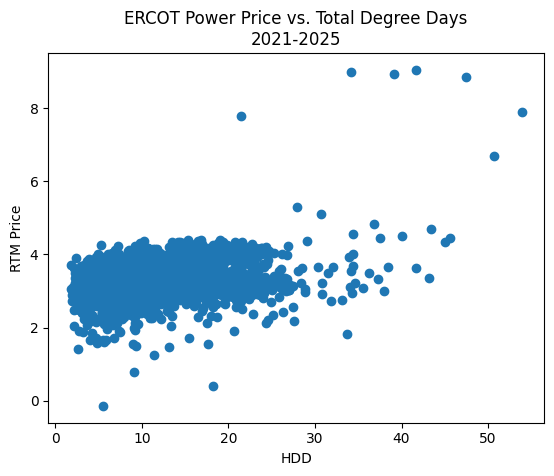

In [10]:
# scatter plot log(rtm price) vs. HDD + CDD,

plt.scatter(df['HDD'] + df['CDD'], np.log(df['avg_rtm_price']))
plt.xlabel('HDD')
plt.ylabel('RTM Price')
plt.title('ERCOT Power Price vs. Total Degree Days\n2021-2025')

plt.savefig(OUT_DIR/'ERCOT Power Price vs. Total Degree Days 2021-2025.png')

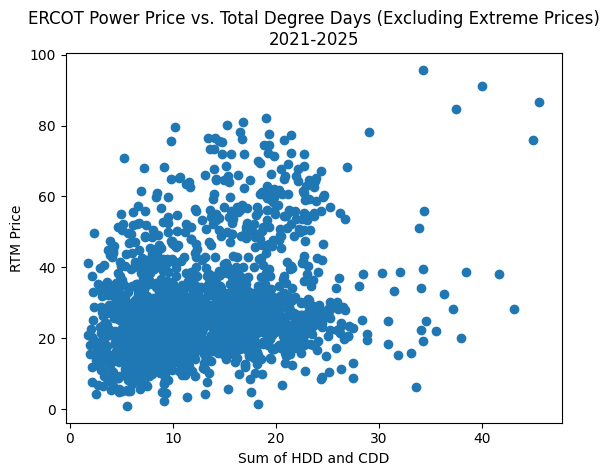

In [11]:
# drop outliers

df_filter = df[df['avg_rtm_price'] < 100]
plt.scatter(df_filter['CDD'] + df_filter['HDD'], df_filter['avg_rtm_price'])
plt.xlabel('Sum of HDD and CDD')
plt.ylabel('RTM Price')
plt.title('ERCOT Power Price vs. Total Degree Days (Excluding Extreme Prices)\n2021-2025')

plt.savefig(OUT_DIR/'ERCOT Power Price vs. Total Degree Days (Excluding Extreme Prices) 2021-2025.png')

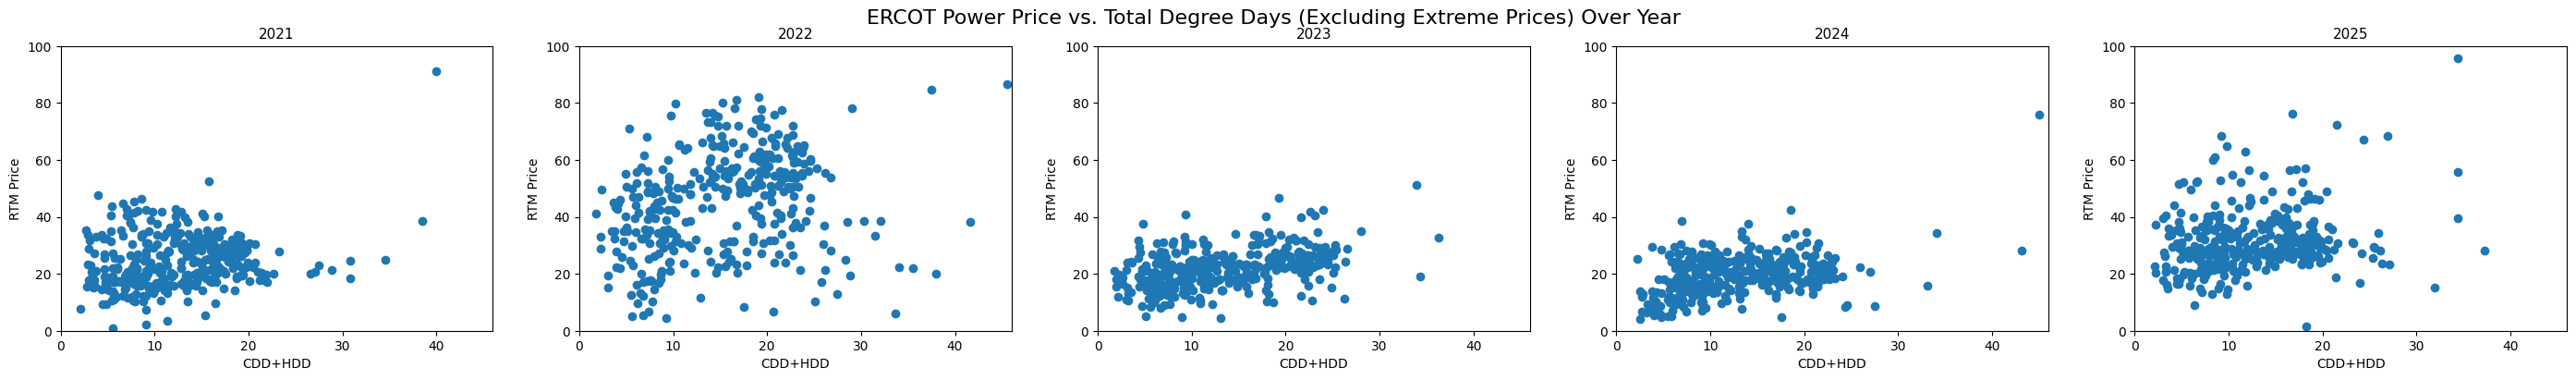

In [26]:
# CDD+HDD vs. price over year
years = [2021, 2022, 2023, 2024, 2025]

fig, axes = plt.subplots(1, 5, figsize=(35, 4))
axes = axes.flatten()

for ax, year in zip(axes, years):
    year_data = df_filter[df_filter['date'].dt.year == year]
    ax.scatter(year_data['CDD'] + year_data['HDD'], year_data['avg_rtm_price'])
    ax.set_title(year, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_xlim(0, 46)
    ax.set_ylabel('RTM Price')
    ax.set_xlabel('CDD+HDD')

fig.suptitle('ERCOT Power Price vs. Total Degree Days (Excluding Extreme Prices) Over Year', fontsize=16)
plt.savefig(OUT_DIR/'ERCOT Power Price vs. Total Degree Days (Excluding Extreme Prices) Over Years 2021-2025.png')
plt.show()

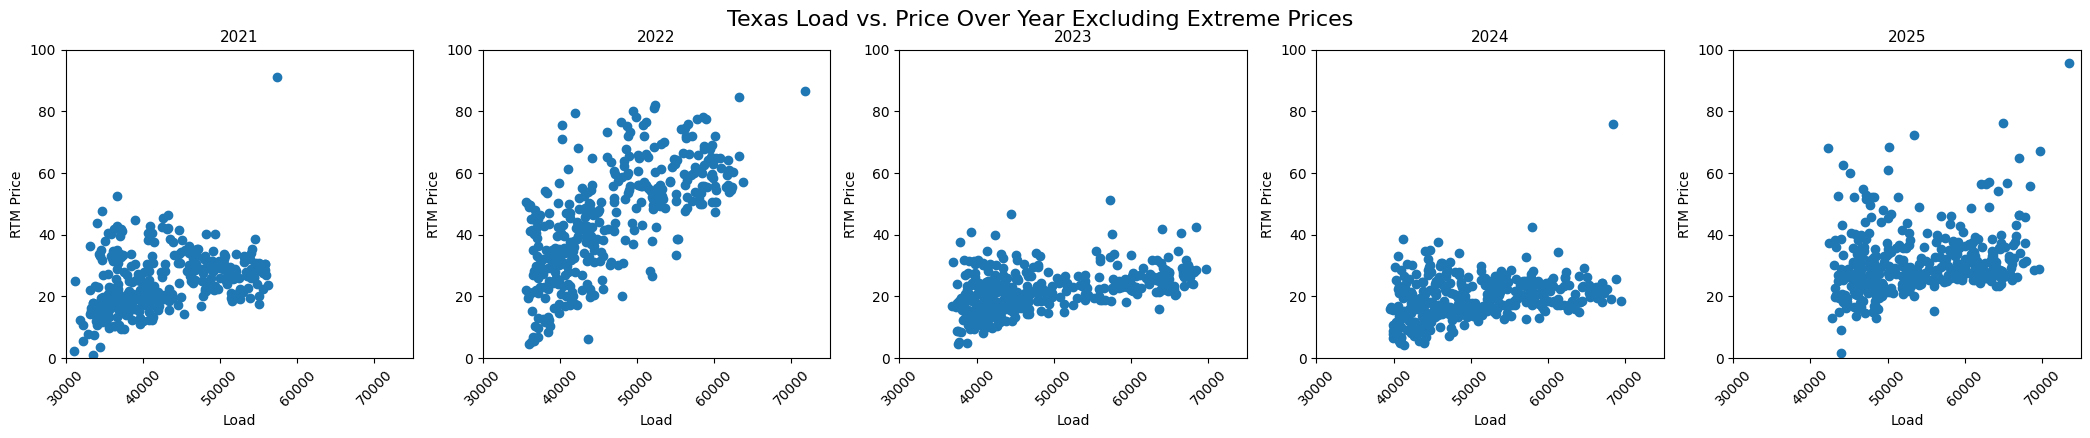

In [27]:
# for reference load vs. price over year
fig, axes = plt.subplots(1, 5, figsize=(26, 4))
axes = axes.flatten()

for ax, year in zip(axes, years):
    year_data = df_filter[df_filter['date'].dt.year == year]
    ax.scatter(year_data['total_load'], year_data['avg_rtm_price'])
    ax.set_title(year, fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 100)
    ax.set_xlim(30000, 75000)
    ax.set_ylabel('RTM Price')
    ax.set_xlabel('Load')

fig.suptitle('Texas Load vs. Price Over Year Excluding Extreme Prices', fontsize=16)
plt.savefig(OUT_DIR/'Texas Load vs. Price Over Year (Excluding Extreme Prices) Over Years 2021-2025.png')
plt.show()

### HDD/CDD vs. load over year

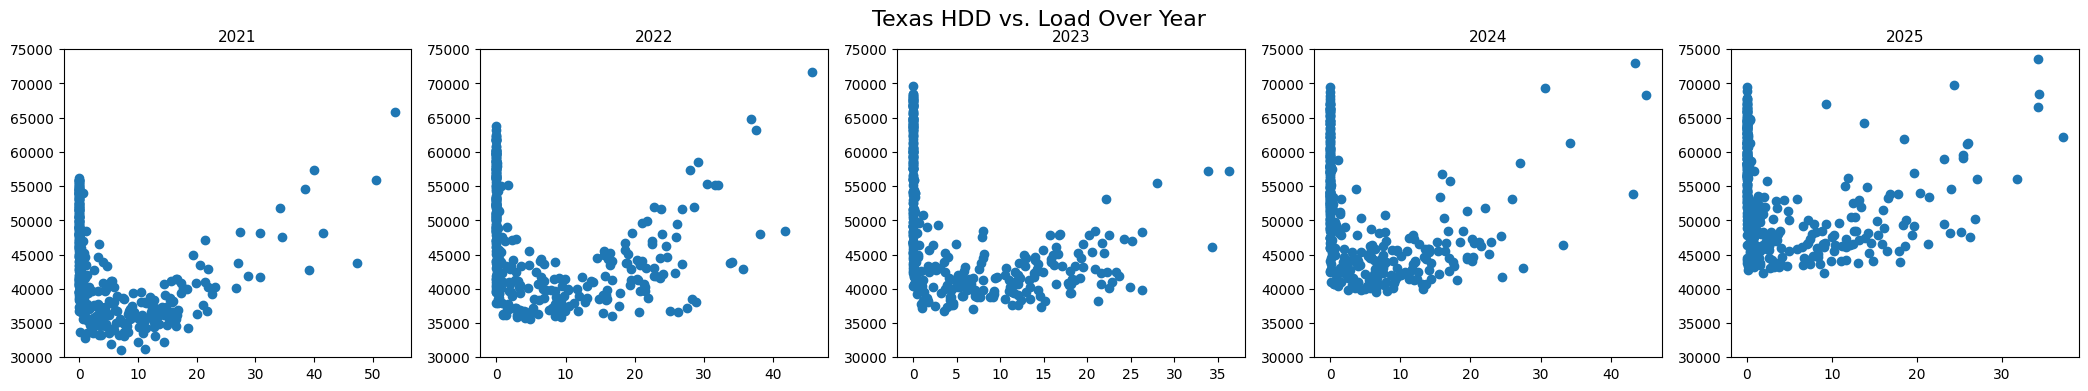

In [14]:
# HDD vs. load over year
years = [2021, 2022, 2023, 2024, 2025]

fig, axes = plt.subplots(1, 5, figsize=(26, 4))
axes = axes.flatten()

for ax, year in zip(axes, years):
    year_data = df[df['date'].dt.year == year]
    ax.scatter(year_data['HDD'], year_data['total_load'])
    ax.set_title(year, fontsize=11)
    ax.set_ylim(30000, 75000)

fig.suptitle('Texas HDD vs. Load Over Year', fontsize=16)
plt.savefig(OUT_DIR/'Texas HDD vs. Load Over Year 2021-2025.png')
plt.show()

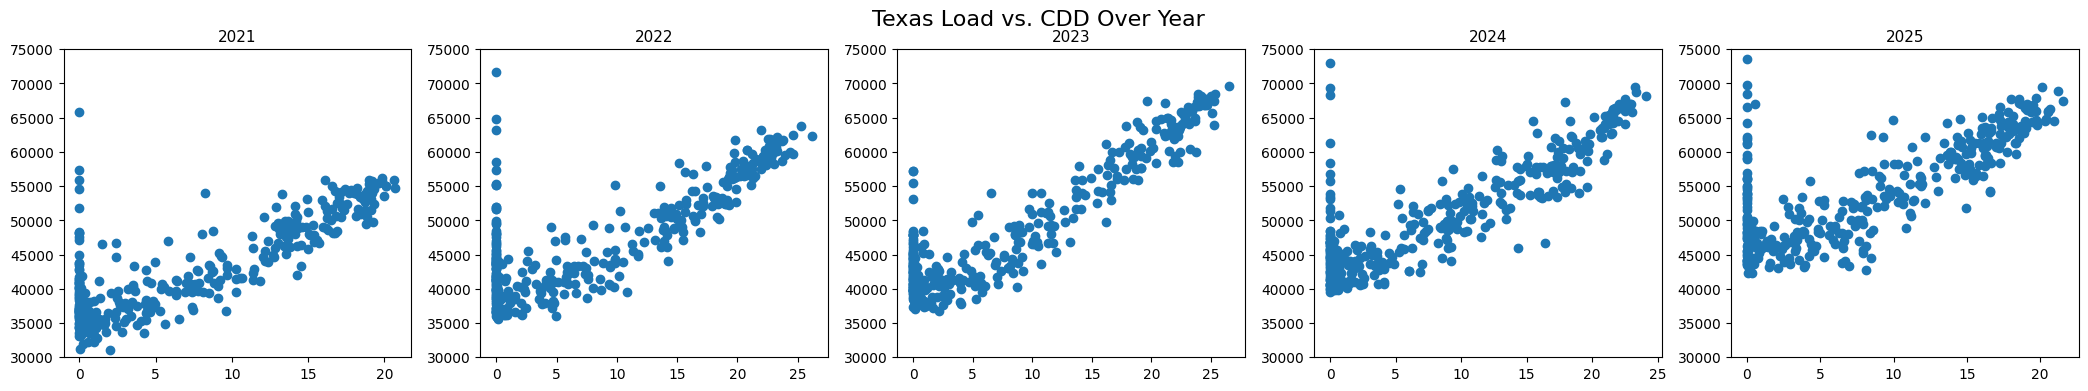

In [20]:
# CDD vs. load over year
years = [2021, 2022, 2023, 2024, 2025]

fig, axes = plt.subplots(1, 5, figsize=(26, 4))
axes = axes.flatten()

for ax, year in zip(axes, years):
    year_data = df[df['date'].dt.year == year]
    ax.scatter(year_data['CDD'], year_data['total_load'])
    ax.set_title(year, fontsize=11)
    ax.set_ylim(30000, 75000)

fig.suptitle('Texas Load vs. CDD Over Year', fontsize=16)
plt.savefig(OUT_DIR/'Texas CDD vs. Load Over Year 2021-2025.png')
plt.show()

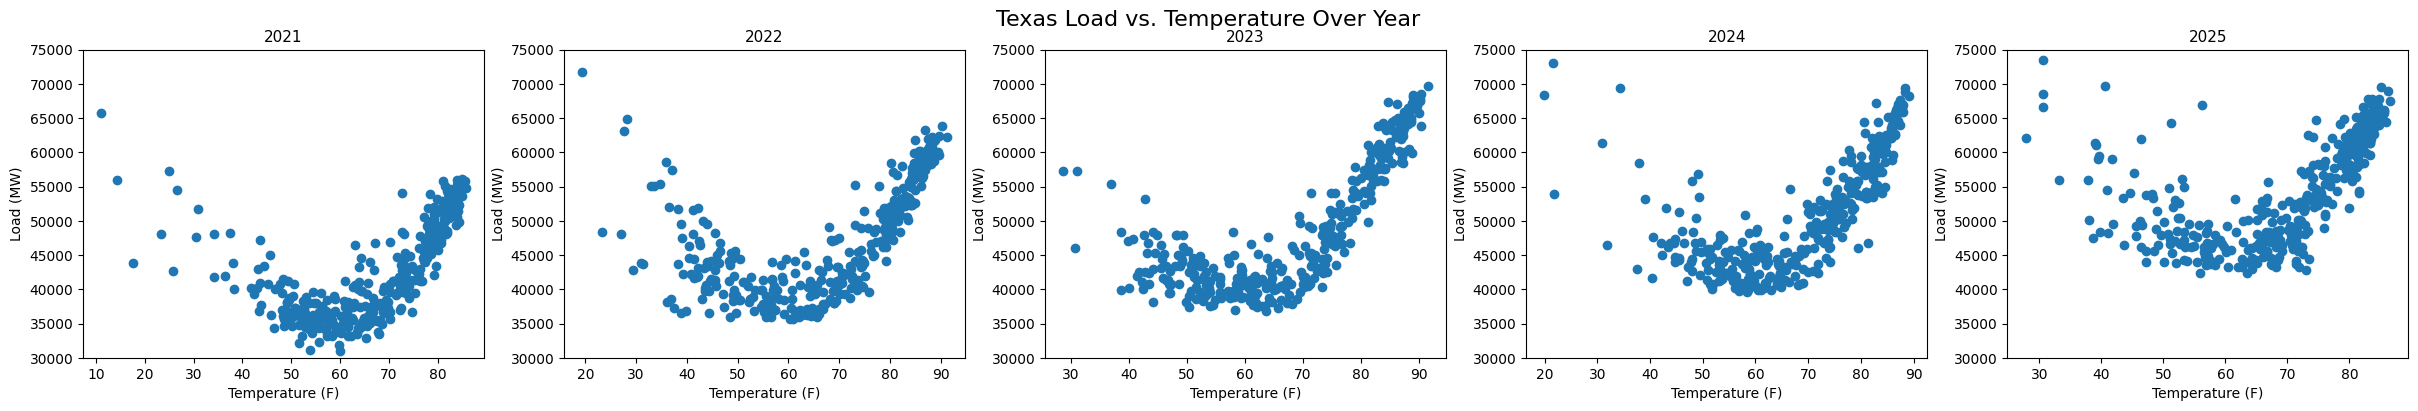

In [19]:
# load vs. temp over year
years = [2021, 2022, 2023, 2024, 2025]

fig, axes = plt.subplots(1, 5, figsize=(30, 4))
axes = axes.flatten()

for ax, year in zip(axes, years):
    year_data = df[df['date'].dt.year == year]
    ax.scatter(year_data['avg_temp_f'], year_data['total_load'])
    ax.set_title(year, fontsize=11)
    ax.set_ylim(30000, 75000)
    ax.set_xlabel("Temperature (F)")
    ax.set_ylabel("Load (MW)")

fig.suptitle('Texas Load vs. Temperature Over Year', fontsize=16)

plt.savefig(OUT_DIR/'Texas Load vs. Temperature Over Year 2021-2025.png')
plt.show()